In [2]:
# ========= חלק 1: הגדרות, יצירת ספקטרוגרמה, טעינת נתונים =========

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms # חשוב ל-Transfer Learning
import torchvision
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.signal import butter, filtfilt, spectrogram
import librosa # חשוב ליצירת Mel-Spectrogram
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import random
from copy import deepcopy
import cv2 # אופציונלי, להתאמת גודל תמונה (pip install opencv-python)

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- הגדרות גלובליות ---
LABEL_MAN = 0
LABEL_CAR = 1
LABEL_NOISE = 2
CLASS_NAMES = ["Steps", "Vehicle", "Noise"]
NUM_CLASSES = 3

window_size = 2000 # אורך חלון מקורי בנקודות דגימה
stride = 500
fs = 1000.0 # קצב דגימה
max_channels = 39 # מספר ערוצים מקסימלי (לפדינג)

# פרמטרים ליצירת ספקטרוגרמה (ניתן לכוונון)
N_MELS = 128      # מספר תדרי Mel (גובה התמונה)
N_FFT = 1024      # גודל חלון FFT
HOP_LENGTH = window_size // (N_MELS * 2) # חפיפה שתיתן רוחב תמונה סביר, נניח 256
# נחשב את רוחב התמונה הצפוי: T = floor(window_size / HOP_LENGTH) + 1
IMG_WIDTH = int(np.floor(window_size / HOP_LENGTH) + 1)
print(f"Spectrogram settings: n_mels={N_MELS}, n_fft={N_FFT}, hop_length={HOP_LENGTH}")
print(f"Expected Spectrogram image size (before resize): ({N_MELS}, {IMG_WIDTH})")

# גודל תמונה סופי עבור ResNet (מודלים של ImageNet)
IMG_HEIGHT_FINAL = 224
IMG_WIDTH_FINAL = 224

# פרמטרים לפילטר (כמו קודם)
lowcut = 1.0
highcut = 100.0
order = 4

# --- פונקציות עזר בסיסיות ---
def pad_channels(data, target_channels):
    if data.ndim == 1: data = data.reshape(-1, 1)
    if data.shape[1] < target_channels:
        padding = np.zeros((data.shape[0], target_channels - data.shape[1]))
        return np.hstack((data, padding))
    elif data.shape[1] > target_channels:
        return data[:, :target_channels]
    return data

def create_windows(signal, label, window_size=window_size, stride=stride):
    X_windows, y_labels = [], []
    if signal.shape[0] < window_size: return [], []
    for start in range(0, signal.shape[0] - window_size + 1, stride):
        X_windows.append(signal[start : start + window_size, :])
        y_labels.append(label)
    return X_windows, y_labels

# --- פונקציה חדשה: יצירת Mel-Spectrogram מחלון ---
def create_mel_spectrogram(window_1d, sr=int(fs), n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS):
    """
    יוצר Mel-Spectrogram מערוץ יחיד של חלון.
    window_1d: מערך numpy 1D של ערוץ אחד.
    """
    try:
        # חישוב Mel-Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=window_1d.astype(np.float32), # ודא float
                                                  sr=sr,
                                                  n_fft=n_fft,
                                                  hop_length=hop_length,
                                                  n_mels=n_mels)
        # המרה ל-dB (סולם לוגריתמי)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # נרמול לטווח [0, 1] (חשוב לקלט של CNN)
        # קודם נזיז כדי שהמינימום יהיה 0, ואז נחלק במקסימום החדש
        min_db = mel_spec_db.min()
        max_db = mel_spec_db.max()
        if max_db > min_db: # מניעת חלוקה באפס
            mel_spec_norm = (mel_spec_db - min_db) / (max_db - min_db)
        else:
            mel_spec_norm = np.zeros_like(mel_spec_db) # אם הכל אותו ערך

        return mel_spec_norm # מחזיר תמונה 2D מנורמלת
        
    except Exception as e:
        print(f"    Warning: Failed to create mel spectrogram: {e}")
        return np.zeros((n_mels, IMG_WIDTH)) # החזר תמונה ריקה במקרה של שגיאה

# --- פונקציה חדשה: טעינת נתונים ויצירת ספקטרוגרמות ---
def load_data_as_spectrograms(file_map, target_img_size=(IMG_HEIGHT_FINAL, IMG_WIDTH_FINAL)):
    """
    טוען נתונים מקבצים, יוצר חלונות, מפעיל פילטר,
    יוצר Mel-Spectrogram מהערוץ הראשון של כל חלון, ומתאים את גודלו.
    """
    all_specs = [] # רשימה לאחסון תמונות הספקטרוגרמה
    all_labels = []
    
    try:
        b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
    except ValueError as e:
        print(f"Error creating filter: {e}. Cannot proceed.")
        return [], []

    print("Loading data and creating spectrograms...")
    for label, info in file_map.items():
        filepath = info['path']
        extra_args = info.get('args', {})
        print(f"  Processing {filepath} for label {label}...")
        try:
            # טעינת הקובץ (עם טיפול בכותרות אפשריות ושגיאות)
            try:
                df = pd.read_csv(filepath, header=None, **extra_args)
            except (pd.errors.ParserError, ValueError):
                 print(f"    Retrying {os.path.basename(filepath)} with skiprows=1")
                 df = pd.read_csv(filepath, header=None, skiprows=1, **extra_args)

            df = df.dropna()
            data = df.values
            if not np.issubdtype(data.dtype, np.number): data = data.astype(float)

            if data.shape[0] < window_size or data.ndim < 2 or data.shape[1] == 0:
                print(f"    Skipping {filepath} (Not enough data or invalid shape: {data.shape})")
                continue

            data_padded = pad_channels(data, max_channels)
            windows, labels = create_windows(data_padded, label)

            if not windows: continue

            print(f"    Created {len(windows)} windows. Filtering and creating spectrograms...")
            count_specs_added = 0
            for i, w in enumerate(windows):
                try:
                    # הפעלת פילטר על החלון
                    filtered_w = filtfilt(b, a, w, axis=0)
                    
                    # יצירת ספקטרוגרמה מהערוץ הראשון
                    # הנחה: הערוץ הראשון הוא המשמעותי ביותר, או שניצור ממוצע/שילוב ערוצים
                    window_channel_0 = filtered_w[:, 0] 
                    mel_spec_norm = create_mel_spectrogram(window_channel_0) # גודל (N_MELS, IMG_WIDTH)

                    # התאמת גודל ל-ResNet (שימוש ב-cv2.resize)
                    if target_img_size is not None:
                        resized_spec = cv2.resize(mel_spec_norm, 
                                                  (target_img_size[1], target_img_size[0]), # (width, height) for cv2
                                                  interpolation=cv2.INTER_LINEAR)
                    else:
                        resized_spec = mel_spec_norm # אם לא רוצים לשנות גודל

                    # ResNet מצפה לקלט של 3 ערוצים (RGB). נשכפל את הספקטרוגרמה 3 פעמים.
                    spec_3_channels = np.stack([resized_spec]*3, axis=0) # צורה: (3, H, W)

                    all_specs.append(spec_3_channels)
                    all_labels.append(labels[i])
                    count_specs_added += 1

                except Exception as e_inner:
                    print(f"    Error processing window {i} from {filepath}: {e_inner}")
            print(f"    Successfully added {count_specs_added} spectrograms from {filepath}")


        except FileNotFoundError:
             print(f"Error: File not found {filepath}. Skipping.")
        except pd.errors.EmptyDataError:
            print(f"Warning: File {os.path.basename(filepath)} is empty. Skipping.")
        except Exception as e:
            print(f"    Error loading/processing {filepath}: {e}")

    if not all_specs:
         print("Warning: No spectrograms were created. Check data paths and processing steps.")
         return np.array([]), np.array([]) # החזר מערכים ריקים

    print(f"\nTotal spectrograms created: {len(all_specs)}")
    # המרה למערכי NumPy בסוף
    return np.array(all_specs, dtype=np.float32), np.array(all_labels, dtype=np.int64)

# --- טעינת הדאטה המקורי כספקטרוגרמות ---
original_file_map = {
    LABEL_MAN: {'path': 'man.csv'},
    LABEL_CAR: {'path': 'car.csv', 'args': {'skiprows': 1}},
    LABEL_NOISE: {'path': 'nothing.csv'}
}
all_original_specs_np, all_original_labels_np = load_data_as_spectrograms(original_file_map)

if all_original_specs_np.size == 0:
    print("CRITICAL ERROR: Failed to load any original data as spectrograms. Exiting.")
    exit()
else:
     print("Original Spectrogram data shape:", all_original_specs_np.shape)
     print("Original Labels shape:", all_original_labels_np.shape)

# --- טעינת הדאטה החדש כספקטרוגרמות (לצורך הערכה) ---
# ניצור file_map זמני עבור הפונקציה הכללית
new_data_folder = 'normalized_csv' # שנה לנתיב הנכון
new_files = glob.glob(os.path.join(new_data_folder, '*.csv'))
new_file_map = {}
if new_files:
    # ניצור מפה עם כל הקבצים תחת תווית 'צעדים' (LABEL_MAN)
    # אם יש קבצים נוספים לקלאסים אחרים, צריך למפות אותם בהתאם
    new_file_map[LABEL_MAN] = {'path': new_files} # שים לב: זה ישלח רשימת קבצים לפונקציה
    # נתאים את הפונקציה load_data_as_spectrograms לטפל בזה:

    def load_data_as_spectrograms_modified(file_map, target_img_size=(IMG_HEIGHT_FINAL, IMG_WIDTH_FINAL)):
        all_specs = [] 
        all_labels = []
        try: b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
        except ValueError as e: print(f"Error creating filter: {e}. Cannot proceed."); return [], []

        print("Loading data and creating spectrograms...")
        for label, info in file_map.items():
            filepaths = info['path'] # Now expects a list
            if isinstance(filepaths, str): filepaths = [filepaths] # Make it a list if single path
            extra_args = info.get('args', {})
            
            for filepath in filepaths: # Iterate through the list of files for this label
                print(f"  Processing {filepath} for label {label}...")
                try:
                    # ... (שאר הלוגיקה של טעינה, יצירת חלונות, פילטור, יצירת ספקטרוגרמה נשארת זהה) ...
                    try: df = pd.read_csv(filepath, header=None, **extra_args)
                    except (pd.errors.ParserError, ValueError): df = pd.read_csv(filepath, header=None, skiprows=1, **extra_args)
                    df = df.dropna(); data = df.values
                    if not np.issubdtype(data.dtype, np.number): data = data.astype(float)
                    if data.shape[0] < window_size or data.ndim < 2 or data.shape[1] == 0: continue
                    data_padded = pad_channels(data, max_channels)
                    windows, labels = create_windows(data_padded, label)
                    if not windows: continue
                    
                    count_specs_added = 0
                    for i, w in enumerate(windows):
                        try:
                            filtered_w = filtfilt(b, a, w, axis=0)
                            window_channel_0 = filtered_w[:, 0] 
                            mel_spec_norm = create_mel_spectrogram(window_channel_0) 
                            if target_img_size is not None:
                                resized_spec = cv2.resize(mel_spec_norm, (target_img_size[1], target_img_size[0]), interpolation=cv2.INTER_LINEAR)
                            else: resized_spec = mel_spec_norm
                            spec_3_channels = np.stack([resized_spec]*3, axis=0) 
                            all_specs.append(spec_3_channels)
                            all_labels.append(labels[i])
                            count_specs_added += 1
                        except Exception as e_inner: print(f"    Error processing window {i} from {filepath}: {e_inner}")
                    #print(f"    Successfully added {count_specs_added} spectrograms from {filepath}")

                except Exception as e: print(f"    Error loading/processing {filepath}: {e}")

        if not all_specs: print("Warning: No spectrograms were created."); return np.array([]), np.array([])
        print(f"\nTotal spectrograms created: {len(all_specs)}")
        return np.array(all_specs, dtype=np.float32), np.array(all_labels, dtype=np.int64)

    new_specs_np, new_labels_np = load_data_as_spectrograms_modified(new_file_map)

else:
    print(f"Warning: No CSV files found in {new_data_folder}. Cannot load new data.")
    new_specs_np, new_labels_np = np.array([]), np.array([])


if new_specs_np.size > 0:
    print("New Spectrogram data shape:", new_specs_np.shape)
    print("New Labels shape:", new_labels_np.shape)

print("\nSpectrogram Data Loading Complete.")

Torch version: 2.6.0+cu118
Torchvision version: 0.21.0+cu118
Using device: cuda
Spectrogram settings: n_mels=128, n_fft=1024, hop_length=7
Expected Spectrogram image size (before resize): (128, 286)
Loading data and creating spectrograms...
  Processing man.csv for label 0...
    Created 65 windows. Filtering and creating spectrograms...
    Successfully added 65 spectrograms from man.csv
  Processing car.csv for label 1...
    Created 30 windows. Filtering and creating spectrograms...
    Successfully added 30 spectrograms from car.csv
  Processing nothing.csv for label 2...
    Created 48 windows. Filtering and creating spectrograms...
    Successfully added 48 spectrograms from nothing.csv

Total spectrograms created: 143
Original Spectrogram data shape: (143, 3, 224, 224)
Original Labels shape: (143,)
Loading data and creating spectrograms...
  Processing normalized_csv\P1_Barefoot_01.csv for label 0...
  Processing normalized_csv\P1_Barefoot_02.csv for label 0...
  Processing norm

In [5]:
# ========= חלק 2: מודל ResNet, Dataset, פונקציות אימון/הערכה =========

# --- הגדרת מודל ResNet ל-Transfer Learning ---
def setup_resnet_model(model_name='resnet18', pretrained=True, num_classes=NUM_CLASSES, freeze_weights=True):
    """
    מגדיר מודל ResNet טעון מראש ומתאים את שכבת הסיווג.
    model_name: 'resnet18', 'resnet34', 'resnet50' וכו'
    pretrained: האם לטעון משקלים מאומנים מראש על ImageNet
    num_classes: מספר הקלאסים שלנו (3)
    freeze_weights: האם להקפיא את כל השכבות פרט לשכבת הסיווג החדשה
    """
    # טעינת המודל המבוקש
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=pretrained)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
    # הוסף עוד מודלים אם רוצים...
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    if freeze_weights and pretrained:
        print(f"Freezing weights for {model_name}...")
        for param in model.parameters():
            param.requires_grad = False

    # קבלת מספר התכונות הנכנסות לשכבת ה-FC האחרונה
    num_ftrs = model.fc.in_features

    # החלפת שכבת ה-FC האחרונה בשכבה חדשה עם הפלט הנכון
    model.fc = nn.Linear(num_ftrs, num_classes)
    print(f"Replaced final FC layer to output {num_classes} classes.")
    
    # ודא שהשכבה החדשה ניתנת לאימון (גם אם הקפאנו את השאר)
    for param in model.fc.parameters():
         param.requires_grad = True

    model = model.to(device) # העבר את המודל ל-GPU/CPU
    return model

# --- Dataset מותאם אישית לספקטרוגרמות ---
# (כולל אפשרות לאוגמנטציה קלה על התמונה אם רוצים)
class SpectrogramDataset(Dataset):
    def __init__(self, specs_np, labels_np, transform=None):
        """
        specs_np: מערך NumPy של ספקטרוגרמות, צורה (N, C, H, W)
        labels_np: מערך NumPy של תוויות
        transform: אופציונלי, טרנספורמציות של torchvision להפעלה על התמונה
        """
        self.specs = torch.from_numpy(specs_np).float() # המרה ל-Tensor פעם אחת
        self.labels = torch.from_numpy(labels_np).long()
        self.transform = transform

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        spec = self.specs[idx]
        if not torch.isfinite(spec).all():
            print(f"Warning: Non-finite values found in spectrogram at index {idx}")
        label = self.labels[idx]

        if self.transform:
            spec = self.transform(spec)

        return spec, label

# --- הגדרת טרנספורמציות (אופציונלי לאוגמנטציה של תמונות) ---
# נרמול לפי ממוצע/סטיית תקן של ImageNet (מומלץ אם משתמשים במשקלים קפואים)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# טרנספורמציות לאימון (כולל אוגמנטציה קלה)
train_transforms = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5), # היפוך אופקי אולי לא רלוונטי לספקטרוגרמה
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0)), # הזזה קטנה בזמן?
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# טרנספורמציות לולידציה/מבחן (רק נרמול)
val_test_transforms = transforms.Compose([
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# --- פונקציות אימון והערכה (דומות לקודם, מותאמות לקלט תמונה) ---
def train_epoch_resnet(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device) # הנתונים כבר Tensor

        optimizer.zero_grad()
        outputs = model(inputs) # קלט (N, C, H, W)
        loss = criterion(outputs, labels)
        preds = outputs.max(1)[1]

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds / total_samples
    return epoch_loss, epoch_acc

def evaluate_model_resnet(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = outputs.max(1)[1]

            running_loss += loss.item() * inputs.size(0)
            correct_preds += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds / total_samples
    return epoch_loss, epoch_acc, all_labels, all_preds

print("ResNet Model, Custom Dataset, and Training/Evaluation Functions Defined.")

ResNet Model, Custom Dataset, and Training/Evaluation Functions Defined.


In [13]:
# ========= חלק 3: K-Fold Cross-Validation עם ResNet (אסטרטגיה 2) =========
from sklearn.metrics import precision_score, recall_score, confusion_matrix
# --- הגדרות אימון ---
N_SPLITS = 5
EPOCHS = 30 # אפשר להתחיל עם פחות אפוקים, כי Transfer Learning יכול להיות מהיר יותר
PATIENCE = 7
BATCH_SIZE = 32 # אפשר להגדיל אם הזיכרון מאפשר
LEARNING_RATE = 0.001 # קצב למידה ראשוני (יכול להיות שצריך נמוך יותר אם לא מקפיאים)
WEIGHT_DECAY = 1e-4
MODEL_NAME = 'resnet18' # או 'resnet34'
FREEZE_WEIGHTS = True # האם להקפיא את רוב המודל ולהתאמן רק על השכבה האחרונה?

# --- הכנת הנתונים (כבר נטענו כספקטרוגרמות) ---
# ודא שהמערכים all_original_specs_np ו-all_original_labels_np תקינים
if all_original_specs_np.size == 0:
     print("Error: Original spectrogram data not loaded. Cannot run K-Fold.")
     exit()

kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=123) # שינוי random_state

fold_results_resnet = []
fold_test_on_new_data_acc_resnet = []

# --- לולאת K-Fold ---
for fold, (train_ids, val_ids) in enumerate(kfold.split(all_original_specs_np, all_original_labels_np)):
    print(f"\n===== FOLD {fold+1}/{N_SPLITS} (ResNet) =====")
    start_fold_time = time.time()

    # --- 1. חלוקת נתונים לפול הנוכחי (ללא אוגמנטציה בשלב זה) ---
    X_train_fold = all_original_specs_np[train_ids]
    y_train_fold = all_original_labels_np[train_ids]
    X_val_fold = all_original_specs_np[val_ids]
    y_val_fold = all_original_labels_np[val_ids]

    print(f"Train fold size: {len(X_train_fold)}")
    print(f"Validation fold size: {len(X_val_fold)}")

    # --- 2. יצירת Datasets ו-DataLoaders עם הטרנספורמציות ---
    # כאן לא מבצעים אוגמנטציה נוספת על הדאטה עצמו, אלא דרך הטרנספורמציות
    train_dataset = SpectrogramDataset(X_train_fold, y_train_fold, transform=train_transforms)
    val_dataset = SpectrogramDataset(X_val_fold, y_val_fold, transform=val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # --- 3. הגדרת המודל, Criterion, Optimizer ---
    model = setup_resnet_model(model_name=MODEL_NAME, pretrained=True,
                               num_classes=NUM_CLASSES, freeze_weights=FREEZE_WEIGHTS)
    criterion = nn.CrossEntropyLoss()

    # בחירת פרמטרים לאימון (רק השכבה האחרונה אם הוקפא, או כולם אם לא)
    params_to_update = []
    print("Parameters to train:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            params_to_update.append(param)
            print(f"\t{name}")

    optimizer = optim.AdamW(params_to_update, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.2, verbose=True) # סקדולר ל-LR

    # --- 4. אימון המודל לפול הנוכחי ---
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    history_resnet = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"Starting training for Fold {fold+1} (ResNet)...")
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch_resnet(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate_model_resnet(model, val_loader, criterion, device)

        print(f"Epoch {epoch}/{EPOCHS} -> "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        history_resnet['train_loss'].append(train_loss)
        history_resnet['train_acc'].append(train_acc)
        history_resnet['val_loss'].append(val_loss)
        history_resnet['val_acc'].append(val_acc)

        scheduler.step(val_acc) # עדכון LR לפי דיוק ולידציה

        # Early Stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  New best validation accuracy: {best_val_acc:.4f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping triggered after {epoch} epochs.")
            break

    fold_results_resnet.append({
    'fold': fold+1, 
    'best_val_acc': best_val_acc, 
    'history': history_resnet, # <<< שמירת ההיסטוריה המלאה
    'new_data_recall': step_recall if best_model_state and new_specs_np.size > 0 else None # שמירת ה-Recall
    })
    print(f"Fold {fold+1} (ResNet) Best Validation Accuracy: {best_val_acc:.4f}")

    # --- 5. הערכה על הדאטהסט החדש (עם המודל הטוב ביותר מהפול) ---
    if best_model_state and new_specs_np.size > 0:
         print(f"Evaluating Fold {fold+1}'s best ResNet model on the new dataset...")
         model.load_state_dict(best_model_state)

         new_dataset = SpectrogramDataset(new_specs_np, new_labels_np, transform=val_test_transforms)
         # המשך עם num_workers=0 לבנתיים, וודא שה-BATCH_SIZE לא גדול מדי לזיכרון
         new_loader = DataLoader(new_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) 

         # הפעלת ההערכה, קבלת רשימת התוויות האמיתיות ורשימת הניבויים
         _, test_acc_new, true_labels_new, predicted_labels_new = evaluate_model_resnet(model, new_loader, criterion, device) 
         # ודא שהפונקציה evaluate_model_resnet מחזירה: loss, acc, all_labels, all_preds
         # all_labels ו-all_preds צריכות להיות רשימות או מערכי NumPy
         
         print(f"  Accuracy on new dataset (Fold {fold+1}, ResNet): {test_acc_new:.4f}")

         # --- חישוב מדדים באמצעות sklearn ---
         # ודא שהתוויות ב-new_labels_np הן אכן LABEL_MAN
         # חשב Recall ו-Precision ספציפית עבור קלאס הצעדים (LABEL_MAN)
         # labels=[LABEL_MAN] -> מחשב את המדד רק עבור הקלאס הזה
         # zero_division=0 -> אם אין דגימות/ניבויים מהקלאס, החזר 0 במקום שגיאה
         step_recall = recall_score(true_labels_new, 
                                     predicted_labels_new, 
                                     labels=[LABEL_MAN], 
                                     average='micro', # או 'binary' if you treat it as one-vs-rest for steps
                                     zero_division=0) 
                                     
         step_precision = precision_score(true_labels_new, 
                                          predicted_labels_new, 
                                          labels=[LABEL_MAN], 
                                          average='micro', # או 'binary'
                                          zero_division=0)

         print(f"  'Steps' Recall on new dataset (Fold {fold+1}, ResNet): {step_recall:.4f}")
         print(f"  'Steps' Precision on new dataset (Fold {fold+1}, ResNet): {step_precision:.4f}")

         # אפשר גם להדפיס את מטריצת הבלבול המלאה על הדאטה החדש
         cm_new = confusion_matrix(true_labels_new, predicted_labels_new, labels=[LABEL_MAN, LABEL_CAR, LABEL_NOISE])
         print("  Confusion Matrix on New Dataset:")
         print(cm_new)

         fold_test_on_new_data_acc_resnet.append(step_recall) 


    elif not new_specs_np.size > 0:
        print("Skipping evaluation on new dataset (no data loaded).")
    else:
         print("Skipping evaluation on new dataset (no best model saved).")

    end_fold_time = time.time()
    print(f"Fold {fold+1} (ResNet) finished in {end_fold_time - start_fold_time:.2f} seconds.")


# --- סיכום תוצאות K-Fold עם ResNet ---
print("\n===== K-Fold Cross-Validation Summary (ResNet) =====")
all_val_accs_resnet = [r['best_val_acc'] for r in fold_results_resnet]
mean_val_acc_resnet = np.mean(all_val_accs_resnet) if all_val_accs_resnet else 0
std_val_acc_resnet = np.std(all_val_accs_resnet) if all_val_accs_resnet else 0
print(f"Average Validation Accuracy across {N_SPLITS} folds (ResNet): {mean_val_acc_resnet:.4f} +/- {std_val_acc_resnet:.4f}")

if fold_test_on_new_data_acc_resnet:
     mean_new_recall = np.mean(fold_test_on_new_data_acc_resnet)
     std_new_recall = np.std(fold_test_on_new_data_acc_resnet)
     print(f"Average 'Steps' Recall on New Dataset across {len(fold_test_on_new_data_acc_resnet)} folds (ResNet): {mean_new_recall:.4f} +/- {std_new_recall:.4f}")
else:
     print("No results for the new dataset were recorded (ResNet).")

# --- (אופציונלי) אימון מודל סופי על כל הדאטה המקורי ---
# אם תוצאות ה-K-Fold נראות מבטיחות, אפשר לאמן מודל ResNet אחד על *כל*
# הדאטה המקורי (all_original_specs_np) למספר האפוקים האופטימלי שנמצא,
# ואז להעריך אותו סופית על הדאטה החדש.


===== FOLD 1/5 (ResNet) =====
Train fold size: 114
Validation fold size: 29


C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freezing weights for resnet18...
Replaced final FC layer to output 3 classes.
Parameters to train:
	fc.weight
	fc.bias
Starting training for Fold 1 (ResNet)...


C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 -> Train Loss: 1.1186, Train Acc: 0.4123 | Val Loss: 0.9300, Val Acc: 0.6552
  New best validation accuracy: 0.6552
Epoch 2/30 -> Train Loss: 0.9256, Train Acc: 0.5351 | Val Loss: 0.9369, Val Acc: 0.7241
  New best validation accuracy: 0.7241
Epoch 3/30 -> Train Loss: 0.8121, Train Acc: 0.6930 | Val Loss: 0.9792, Val Acc: 0.5862
Epoch 4/30 -> Train Loss: 0.6580, Train Acc: 0.8421 | Val Loss: 0.9180, Val Acc: 0.6207
Epoch 5/30 -> Train Loss: 0.5649, Train Acc: 0.9035 | Val Loss: 0.8563, Val Acc: 0.6207
Epoch 6/30 -> Train Loss: 0.4691, Train Acc: 0.9474 | Val Loss: 0.8067, Val Acc: 0.6207
Epoch 7/30 -> Train Loss: 0.4248, Train Acc: 0.9737 | Val Loss: 0.7618, Val Acc: 0.5862
Epoch 8/30 -> Train Loss: 0.4068, Train Acc: 0.9649 | Val Loss: 0.7092, Val Acc: 0.6552
Epoch 9/30 -> Train Loss: 0.3956, Train Acc: 0.9737 | Val Loss: 0.6562, Val Acc: 0.7586
  New best validation accuracy: 0.7586
Epoch 10/30 -> Train Loss: 0.3921, Train Acc: 0.9649 | Val Loss: 0.6044, Val Acc: 0.8621
  

...

Epoch 1/30 -> Train Loss: 1.1729, Train Acc: 0.3772 | Val Loss: 1.0931, Val Acc: 0.4483
  New best validation accuracy: 0.4483
Epoch 2/30 -> Train Loss: 1.0071, Train Acc: 0.5439 | Val Loss: 1.0289, Val Acc: 0.5172
  New best validation accuracy: 0.5172
Epoch 3/30 -> Train Loss: 0.8387, Train Acc: 0.6316 | Val Loss: 1.0046, Val Acc: 0.5517
  New best validation accuracy: 0.5517
Epoch 4/30 -> Train Loss: 0.7091, Train Acc: 0.8158 | Val Loss: 0.9224, Val Acc: 0.6207
  New best validation accuracy: 0.6207
Epoch 5/30 -> Train Loss: 0.5996, Train Acc: 0.9474 | Val Loss: 0.8513, Val Acc: 0.6207
Epoch 6/30 -> Train Loss: 0.5148, Train Acc: 0.9474 | Val Loss: 0.7989, Val Acc: 0.5172
Epoch 7/30 -> Train Loss: 0.4404, Train Acc: 0.9561 | Val Loss: 0.7696, Val Acc: 0.5172
Epoch 8/30 -> Train Loss: 0.4031, Train Acc: 0.9825 | Val Loss: 0.6952, Val Acc: 0.7241
  New best validation accuracy: 0.7241
Epoch 9/30 -> Train Loss: 0.3433, Train Acc: 0.9737 | Val Loss: 0.6335, Val Acc: 0.8621
  New best va

C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarn

Freezing weights for resnet18...
Replaced final FC layer to output 3 classes.
Parameters to train:
	fc.weight
	fc.bias
Starting training for Fold 4 (ResNet)...
Epoch 1/30 -> Train Loss: 0.9539, Train Acc: 0.5826 | Val Loss: 1.1949, Val Acc: 0.3214
  New best validation accuracy: 0.3214
Epoch 2/30 -> Train Loss: 0.7860, Train Acc: 0.7130 | Val Loss: 0.9976, Val Acc: 0.3214
Epoch 3/30 -> Train Loss: 0.6879, Train Acc: 0.6696 | Val Loss: 0.9037, Val Acc: 0.5000
  New best validation accuracy: 0.5000
Epoch 4/30 -> Train Loss: 0.5370, Train Acc: 0.9565 | Val Loss: 0.9409, Val Acc: 0.3929
Epoch 5/30 -> Train Loss: 0.4870, Train Acc: 0.9652 | Val Loss: 0.8985, Val Acc: 0.4643
Epoch 6/30 -> Train Loss: 0.4048, Train Acc: 0.9826 | Val Loss: 0.7929, Val Acc: 0.6071
  New best validation accuracy: 0.6071
Epoch 7/30 -> Train Loss: 0.3318, Train Acc: 0.9913 | Val Loss: 0.6801, Val Acc: 0.6429
  New best validation accuracy: 0.6429
Epoch 8/30 -> Train Loss: 0.3274, Train Acc: 0.9391 | Val Loss: 0.61

C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\lidor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarn

Freezing weights for resnet18...
Replaced final FC layer to output 3 classes.
Parameters to train:
	fc.weight
	fc.bias
Starting training for Fold 5 (ResNet)...
Epoch 1/30 -> Train Loss: 1.0675, Train Acc: 0.4261 | Val Loss: 1.0769, Val Acc: 0.5357
  New best validation accuracy: 0.5357
Epoch 2/30 -> Train Loss: 0.8709, Train Acc: 0.5304 | Val Loss: 1.1097, Val Acc: 0.3214
Epoch 3/30 -> Train Loss: 0.7497, Train Acc: 0.7913 | Val Loss: 1.0898, Val Acc: 0.3214
Epoch 4/30 -> Train Loss: 0.6224, Train Acc: 0.9304 | Val Loss: 0.9513, Val Acc: 0.4643
Epoch 5/30 -> Train Loss: 0.5545, Train Acc: 0.9478 | Val Loss: 0.8074, Val Acc: 0.6786
  New best validation accuracy: 0.6786
Epoch 6/30 -> Train Loss: 0.4719, Train Acc: 0.9565 | Val Loss: 0.7331, Val Acc: 0.7143
  New best validation accuracy: 0.7143
Epoch 7/30 -> Train Loss: 0.4051, Train Acc: 0.9739 | Val Loss: 0.6686, Val Acc: 0.6429
Epoch 8/30 -> Train Loss: 0.3598, Train Acc: 0.9652 | Val Loss: 0.6134, Val Acc: 0.6786
Epoch 9/30 -> Train


--- Plotting Average K-Fold Performance (ResNet) ---


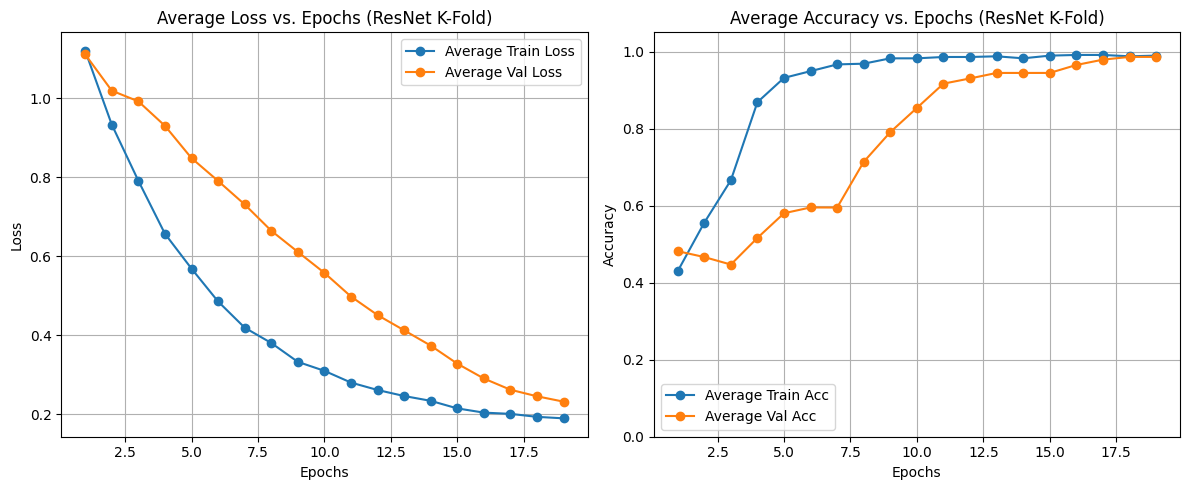


--- Plotting Final K-Fold Results Distribution (ResNet) ---


C:\Users\lidor\AppData\Local\Temp\ipykernel_81144\423917024.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([final_val_accs, final_new_data_recalls] if final_new_data_recalls else [final_val_accs],


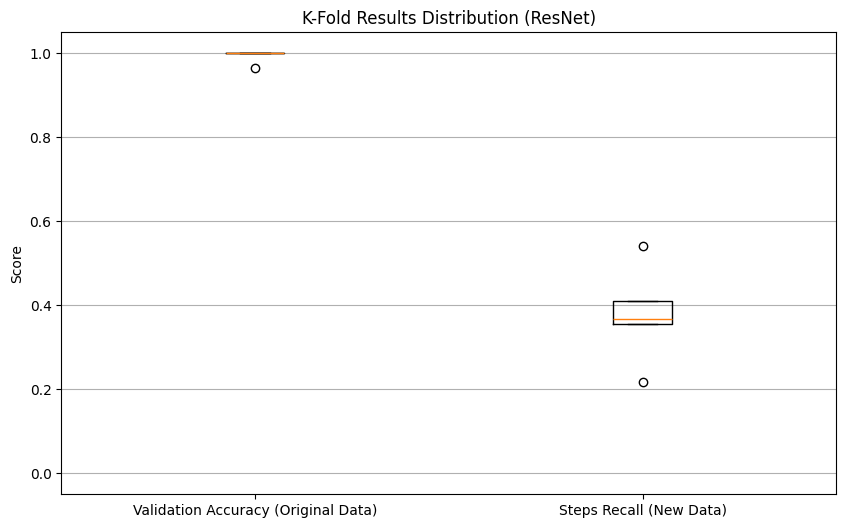

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. גרף Loss ו-Accuracy ממוצע על פני הפולים ---
# (דורש שההיסטוריה מכל פול נשמרה באורך זהה או מרופדת)

print("\n--- Plotting Average K-Fold Performance (ResNet) ---")

# מצא את האורך המינימלי של ההיסטוריה בין כל הפולים (בגלל Early Stopping)
min_epochs = min(len(r['history']['val_loss']) for r in fold_results_resnet if r['history']) if fold_results_resnet else 0

if min_epochs > 0:
    avg_train_loss = np.zeros(min_epochs)
    avg_val_loss = np.zeros(min_epochs)
    avg_train_acc = np.zeros(min_epochs)
    avg_val_acc = np.zeros(min_epochs)
    valid_folds = 0

    for result in fold_results_resnet:
        if result['history']:
            valid_folds += 1
            # חתוך את ההיסטוריה לאורך המינימלי
            avg_train_loss += np.array(result['history']['train_loss'][:min_epochs])
            avg_val_loss += np.array(result['history']['val_loss'][:min_epochs])
            avg_train_acc += np.array(result['history']['train_acc'][:min_epochs])
            avg_val_acc += np.array(result['history']['val_acc'][:min_epochs])

    if valid_folds > 0:
        avg_train_loss /= valid_folds
        avg_val_loss /= valid_folds
        avg_train_acc /= valid_folds
        avg_val_acc /= valid_folds

        epochs_range = range(1, min_epochs + 1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, avg_train_loss, 'o-', label='Average Train Loss')
        plt.plot(epochs_range, avg_val_loss, 'o-', label='Average Val Loss')
        plt.title('Average Loss vs. Epochs (ResNet K-Fold)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, avg_train_acc, 'o-', label='Average Train Acc')
        plt.plot(epochs_range, avg_val_acc, 'o-', label='Average Val Acc')
        plt.title('Average Accuracy vs. Epochs (ResNet K-Fold)')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.ylim(0, 1.05) # הגבלת ציר Y

        plt.tight_layout()
        plt.show()
    else:
        print("Could not plot average performance: No valid history found.")

else:
    print("Could not plot average performance: Minimum epochs is 0.")


# --- 2. גרף Box Plot של התוצאות הסופיות ---

print("\n--- Plotting Final K-Fold Results Distribution (ResNet) ---")

final_val_accs = [r['best_val_acc'] for r in fold_results_resnet]
# Filter out None values if evaluation on new data failed for some folds
final_new_data_recalls = [r['new_data_recall'] for r in fold_results_resnet if r.get('new_data_recall') is not None] 

plt.figure(figsize=(10, 6))

plt.boxplot([final_val_accs, final_new_data_recalls] if final_new_data_recalls else [final_val_accs], 
            labels=['Validation Accuracy (Original Data)', 'Steps Recall (New Data)'] if final_new_data_recalls else ['Validation Accuracy (Original Data)'])
plt.title('K-Fold Results Distribution (ResNet)')
plt.ylabel('Score')
plt.grid(True, axis='y')
plt.ylim(-0.05, 1.05) # ציר Y מ-0 עד 1

plt.show()

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import random
import librosa
import librosa.display
import pandas as pd
from scipy.signal import spectrogram, butter, filtfilt # ודא שכל הייבואים קיימים
import glob # צריך עבור load_new_dataset
import os   # צריך עבור load_new_dataset

# --- הגדרות גלובליות (ודא שהן תואמות להגדרות האימון!) ---
LABEL_MAN = 0
window_size = 2000
stride = 500 # או מה שהשתמשת בו
fs = 1000.0
lowcut = 1.0
highcut = 100.0
order = 4
max_channels = 39 # או מה שחושב אצלך

# --- פונקציות עזר (צריכות להיות מוגדרות כאן או מיובאות) ---

def pad_channels(data, target_channels):
    # ... (הקוד של הפונקציה שלך) ...
    if data.ndim == 1: # Handle potential 1D data if read incorrectly
        print(f"Warning: pad_channels received 1D data of shape {data.shape}. Reshaping.")
        data = data.reshape(-1, 1) # Reshape to (n_samples, 1 channel)

    if data.shape[1] < target_channels:
        padding = np.zeros((data.shape[0], target_channels - data.shape[1]))
        data_padded = np.hstack((data, padding))
        return data_padded
    elif data.shape[1] > target_channels:
         # קיצוץ אם יש יותר ערוצים משנדרש
         return data[:, :target_channels]
    else:
        return data


def create_windows(signal, label, window_size=window_size, stride=stride):
    # ... (הקוד של הפונקציה שלך, ודא שמשתמשת ב-window_size/stride הנכונים) ...
    X_windows = []
    y_labels = []
    num_samples = signal.shape[0]
    if num_samples < window_size:
        return [], [] # Skip if signal is shorter than window size

    for start in range(0, num_samples - window_size + 1, stride):
        end = start + window_size
        X_windows.append(signal[start:end, :])
        y_labels.append(label) # Assuming label is constant for the whole file here
    return X_windows, y_labels

# פונקציה לטעינת הדאטהסט החדש (כמו בעמוד 19, עם תיקונים קלים)
def load_new_dataset(folder_path='normalized_csv', target_label=LABEL_MAN): # Added target_label
    """מהתיקייה CSV-טעינת כל קבצי ה"""
    print(f"...טוען נתונים חדשים מתיקייה: {folder_path}...")
    all_windows = []
    all_labels = []

    # יצירת פילטר באנד-פס
    try:
      b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
    except ValueError as e:
      print(f"Error creating filter: {e}. Check filter parameters and fs.")
      return [], []


    csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    if not csv_files:
        print(f"Warning: No CSV files found in {folder_path}")
        return [], []
    print(f"נמצאו {len(csv_files)} קבצי CSV")

    for csv_file in csv_files:
        try:
            # טעינת הקובץ, דילוג על שורת כותרת אם יש, ללא כותרת מפורשת
            # ננסה בלי skiprows תחילה, אם יש שגיאה ננסה עם
            try:
                df = pd.read_csv(csv_file, header=None)
            except pd.errors.ParserError:
                 print(f"  Retrying {os.path.basename(csv_file)} with skiprows=1")
                 df = pd.read_csv(csv_file, header=None, skiprows=1)

            df = df.dropna() # הסרת שורות עם ערכים חסרים
            data = df.values

            # בדיקה אם הנתונים מספריים
            if not np.issubdtype(data.dtype, np.number):
                 print(f"  Warning: Non-numeric data found in {os.path.basename(csv_file)}. Attempting conversion...")
                 try:
                     data = data.astype(float)
                 except ValueError:
                     print(f"  Error: Could not convert data to numeric in {os.path.basename(csv_file)}. Skipping file.")
                     continue


            # בדיקה אם יש נתונים תקינים
            if data.shape[0] < window_size:
                print(f"  דילוג על קובץ {os.path.basename(csv_file)}: מספר דגימות נמוך מדי ({data.shape[0]})")
                continue
            if data.ndim < 2 or data.shape[1] == 0:
                 print(f"  דילוג על קובץ {os.path.basename(csv_file)}: נתונים לא תקינים (צורה {data.shape}).")
                 continue

            #print(f"  מעבד קובץ {os.path.basename(csv_file)}: {data.shape[0]} דגימות, {data.shape[1]} ערוצים")

            # פדינג/קיצוץ ערוצים
            data_padded = pad_channels(data, max_channels)

            # חלוקה לחלונות - כל החלונות מהקובץ מקבלים את אותה תווית
            windows_from_file, labels_from_file = create_windows(data_padded, target_label, window_size, stride)

            # הפעלת הפילטר על כל חלון
            filtered_windows = []
            if windows_from_file: # Check if any windows were created
              try:
                filtered_windows = [filtfilt(b, a, w, axis=0) for w in windows_from_file]
              except ValueError as e:
                 print(f"  Error applying filter to {os.path.basename(csv_file)}: {e}. Skipping file.")
                 continue

            # הוספה לרשימה הכללית
            all_windows.extend(filtered_windows)
            all_labels.extend(labels_from_file[:len(filtered_windows)]) # Match labels count

        except FileNotFoundError:
             print(f"Error: File not found {csv_file}. Skipping.")
        except pd.errors.EmptyDataError:
            print(f"Warning: File {os.path.basename(csv_file)} is empty. Skipping.")
        except Exception as e:
            print(f"שגיאה בטעינת/עיבוד קובץ {os.path.basename(csv_file)}: {str(e)}")

    print(f"סה\"כ נוצרו {len(all_windows)} חלונות מהנתונים החדשים.")
    return all_windows, all_labels

# --- טעינת הנתונים המקוריים והחדשים ---
# ודא שהמשתנה original_step_windows_full זמין (למשל, טען מ-man_wins)
# לדוגמה:
try:
    original_step_windows_full = man_wins # או טען מחדש אם צריך
    if not original_step_windows_full:
        print("Error: original_step_windows_full is empty or not loaded.")
        # הוסף כאן קוד לטעינה מחדש אם צריך
except NameError:
    print("Error: Variable 'man_wins' not defined. Load original step data first.")
    original_step_windows_full = [] # Set to empty list to avoid further errors

# טעינת הנתונים החדשים באמצעות הפונקציה
new_step_windows_full, new_step_labels_full = load_new_dataset(folder_path='normalized_csv', target_label=LABEL_MAN) # השתמש בנתיב הנכון


# --- המשך קוד ההשוואה (כמו קודם) ---

# ודא שיש נתונים להצגה
if not original_step_windows_full or not new_step_windows_full:
    print("שגיאה: לא נמצאו מספיק נתונים להשוואה.")
else:
    # --- דגימה אקראית ---
    num_original = len(original_step_windows_full)
    num_new = len(new_step_windows_full)
    
    original_indices = random.sample(range(num_original), min(N_SAMPLES_TO_SHOW, num_original))
    new_indices = random.sample(range(num_new), min(N_SAMPLES_TO_SHOW, num_new))
    
    sampled_original = [original_step_windows_full[i] for i in original_indices]
    sampled_new = [new_step_windows_full[i] for i in new_indices]

    # --- 1. ויזואליזציה: השוואת צורות גל ---
    print("\n--- השוואת צורות גל (דוגמאות אקראיות) ---")
    # ... (קוד ההצגה של צורות הגל) ...
    fig_signal, axes_signal = plt.subplots(2, N_SAMPLES_TO_SHOW, 
                                           figsize=(15, 6), sharey=True)
    fig_signal.suptitle('Signal Waveforms (First Channel)')
    
    for i in range(N_SAMPLES_TO_SHOW):
        if i < len(sampled_original):
            axes_signal[0, i].plot(sampled_original[i][:, 0])
            axes_signal[0, i].set_title(f'Original Step {original_indices[i]}')
            axes_signal[0, i].grid(True)
        if i < len(sampled_new):
            axes_signal[1, i].plot(sampled_new[i][:, 0])
            axes_signal[1, i].set_title(f'New Step {new_indices[i]}')
            axes_signal[1, i].grid(True)
            
    axes_signal[0, 0].set_ylabel('Original Amplitude')
    axes_signal[1, 0].set_ylabel('New Amplitude')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()

    # --- 2. ויזואליזציה: השוואת ספקטרוגרמות ---
    print("\n--- השוואת ספקטרוגרמות (דוגמאות אקראיות) ---")
    # ... (קוד ההצגה של ספקטרוגרמות) ...
    fig_spec, axes_spec = plt.subplots(2, N_SAMPLES_TO_SHOW, 
                                       figsize=(15, 7), sharey=True)
    fig_spec.suptitle('Spectrograms (First Channel)')
    
    all_sxx = []
    for win in sampled_original + sampled_new:
        if win.ndim >= 2 and win.shape[1] > 0:
             try:
               f, t, Sxx = spectrogram(win[:, 0], fs=FS)
               all_sxx.append(10 * np.log10(Sxx + 1e-9)) 
             except Exception as e:
                print(f"Warning: Spectrogram calculation failed for a window: {e}")

    vmin = np.percentile(np.concatenate(all_sxx), 5) if all_sxx else -60 # Default vmin
    vmax = np.percentile(np.concatenate(all_sxx), 95) if all_sxx else -10 # Default vmax

    for i in range(N_SAMPLES_TO_SHOW):
        if i < len(sampled_original):
             if sampled_original[i].ndim >= 2 and sampled_original[i].shape[1] > 0:
                 try:
                    f, t, Sxx = spectrogram(sampled_original[i][:, 0], fs=FS)
                    img = axes_spec[0, i].pcolormesh(t, f, 10 * np.log10(Sxx + 1e-9), 
                                                    shading='gouraud', cmap='magma', vmin=vmin, vmax=vmax)
                    axes_spec[0, i].set_title(f'Original Step {original_indices[i]}')
                    axes_spec[0, i].set_ylim(0, 150) 
                 except Exception as e:
                     axes_spec[0,i].set_title(f'Original Step {original_indices[i]}\nSpectrogram Error')
        if i < len(sampled_new):
             if sampled_new[i].ndim >= 2 and sampled_new[i].shape[1] > 0:
                try:
                    f, t, Sxx = spectrogram(sampled_new[i][:, 0], fs=FS)
                    img = axes_spec[1, i].pcolormesh(t, f, 10 * np.log10(Sxx + 1e-9), 
                                                    shading='gouraud', cmap='magma', vmin=vmin, vmax=vmax)
                    axes_spec[1, i].set_title(f'New Step {new_indices[i]}')
                    axes_spec[1, i].set_ylim(0, 150)
                except Exception as e:
                     axes_spec[1,i].set_title(f'New Step {new_indices[i]}\nSpectrogram Error')
            
    axes_spec[0, 0].set_ylabel('Original Freq [Hz]')
    axes_spec[1, 0].set_ylabel('New Freq [Hz]')
    if 'img' in locals(): # Check if img was created
      fig_spec.colorbar(img, ax=axes_spec.ravel().tolist(), label='Intensity [dB]')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    # --- 3. סטטיסטיקה: השוואת תכונות בסיסיות ---
    print("\n--- השוואת סטטיסטיקות (ממוצע על כל החלונות) ---")
    # ... (פונקציה calculate_stats כמו בקוד הקודם, עם try-except עבור librosa) ...
    def calculate_stats(window_list):
        stats = []
        if not window_list: # בדיקה אם הרשימה ריקה
            return pd.DataFrame() 
        for win in window_list:
            if win.ndim >= 2 and win.shape[1] > 0: # Check if window is valid 2D and has channels
              signal = win[:, 0] # ערוץ ראשון
              rms = np.sqrt(np.mean(signal**2))
              std = np.std(signal)
              max_abs = np.max(np.abs(signal))
              # Spectral Centroid 
              try: # Add try-except for librosa call
                spec_centroid = librosa.feature.spectral_centroid(y=signal.astype(np.float32), sr=int(FS))[0] # Ensure float32
                mean_spec_centroid = np.mean(spec_centroid) if spec_centroid.size > 0 else 0
              except Exception as e:
                #print(f"Warning: Spectral centroid calculation failed: {e}")
                mean_spec_centroid = 0 # Set to 0 or NaN on failure
              
              stats.append({
                  'RMS': rms,
                  'Std Dev': std,
                  'Max Abs': max_abs,
                  'Mean Spectral Centroid (Hz)': mean_spec_centroid
              })
            else:
                 #print(f"Warning: Skipping invalid window with shape {win.shape}")
                 pass # Or log appropriately

        return pd.DataFrame(stats)

    original_stats_df = calculate_stats(original_step_windows_full) 
    new_stats_df = calculate_stats(new_step_windows_full)   
    
    # ... (קוד ההדפסה והצגת Box Plots כמו קודם, עם בדיקות אם הדאטה ריק) ...
    if not original_stats_df.empty and not new_stats_df.empty:
        comparison_stats = pd.DataFrame({
            'Original Mean': original_stats_df.mean(),
            'Original Std': original_stats_df.std(),
            'New Mean': new_stats_df.mean(),
            'New Std': new_stats_df.std()
        })
        print(comparison_stats)
    else:
        print("לא ניתן לחשב סטטיסטיקות השוואתיות (אחד הדאטהסטים ריק או לא תקין).")

    if not original_stats_df.empty and not new_stats_df.empty:
        print("\n--- השוואת התפלגות סטטיסטיקות (Box Plots) ---")
        fig_stats, axes_stats = plt.subplots(1, 4, figsize=(18, 5))
        fig_stats.suptitle('Distribution Comparison of Features (First Channel)')
    
        stats_to_plot = ['RMS', 'Std Dev', 'Max Abs', 'Mean Spectral Centroid (Hz)']
    
        for i, stat_name in enumerate(stats_to_plot):
            if stat_name in original_stats_df.columns and stat_name in new_stats_df.columns:
                data_to_plot = [original_stats_df[stat_name].dropna(), 
                                new_stats_df[stat_name].dropna()]
                data_to_plot = [d for d in data_to_plot if len(d) > 0] 
                if len(data_to_plot) == 2: 
                   axes_stats[i].boxplot(data_to_plot, labels=['Original', 'New'])
                elif len(data_to_plot) == 1: 
                   axes_stats[i].boxplot(data_to_plot, labels=['Original' if len(original_stats_df[stat_name].dropna()) > 0 else 'New'])
                axes_stats[i].set_title(stat_name)
                axes_stats[i].grid(True, axis='y')
            else:
                 axes_stats[i].set_title(f'{stat_name}\n(Data missing)')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
         print("לא ניתן להציג Box Plots (אחד הדאטהסטים ריק או לא תקין).")

...טוען נתונים חדשים מתיקייה: normalized_csv...
נמצאו 354 קבצי CSV


KeyboardInterrupt: 